In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [6]:
train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

print("Full Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

train_df.head()


Full Training Data Shape: (27455, 785)
Testing Data Shape: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [7]:
train_sample = train_df.sample(n=5000, random_state=42).reset_index(drop=True)

print("Sampled Training Data Shape:", train_sample.shape)


Sampled Training Data Shape: (5000, 785)


In [8]:
X_train = train_sample.drop("label", axis=1).values
y_train_original = train_sample["label"].values

X_test = test_df.drop("label", axis=1).values
y_test_original = test_df["label"].values

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train_original.shape)
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test_original.shape)


X_train Shape: (5000, 784)
y_train Shape: (5000,)
X_test Shape: (7172, 784)
y_test Shape: (7172,)


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train_original)
y_test = le.transform(y_test_original)

n_classes = len(le.classes_)

print("Classes:", le.classes_)
print("Number of Classes:", n_classes)


Classes: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Number of Classes: 24


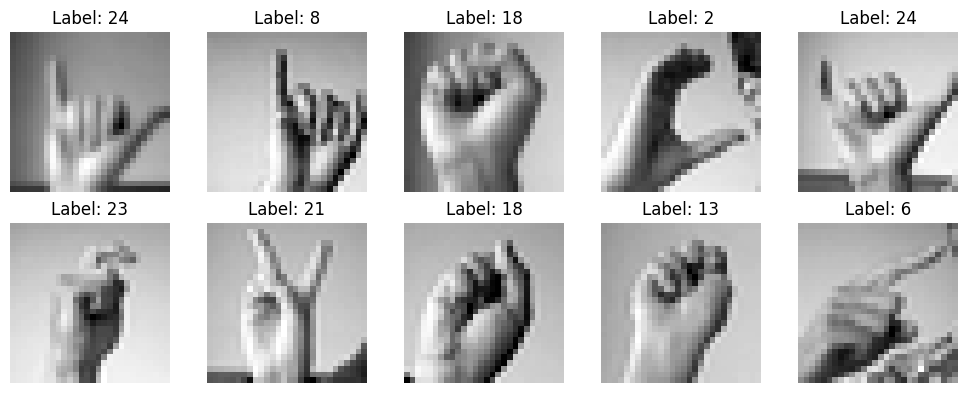

In [10]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train_original[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [11]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum Training Pixel Value:", X_train.min())
print("Maximum Training Pixel Value:", X_train.max())


Minimum Training Pixel Value: 0.0
Maximum Training Pixel Value: 1.0


In [12]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("New Training Shape:", X_train.shape)
print("New Testing Shape:", X_test.shape)


New Training Shape: (5000, 28, 28, 1)
New Testing Shape: (7172, 28, 28, 1)


In [13]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(n_classes, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,840 (479.84 KB)

 Trainable params: 122,840 (479.84 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.1730 - loss: 2.9865 - val_accuracy: 0.2720 - val_loss: 2.4183
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.4577 - loss: 1.7685 - val_accuracy: 0.6000 - val_loss: 1.2711
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6693 - loss: 1.0647 - val_accuracy: 0.7430 - val_loss: 0.8466
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.7690 - loss: 0.7309 - val_accuracy: 0.7860 - val_loss: 0.6660
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8355 - loss: 0.5625 - val_accuracy: 0.8530 - val_loss: 0.4970
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8770 - loss: 0.4194 - val_accuracy: 0.8840 - val_loss: 0.3776
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9105 - loss: 0.3260 - val_accuracy: 0.9000 - val_loss: 0.3158
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9245 - loss: 0.2603 - val_accuracy: 0.9060 - v

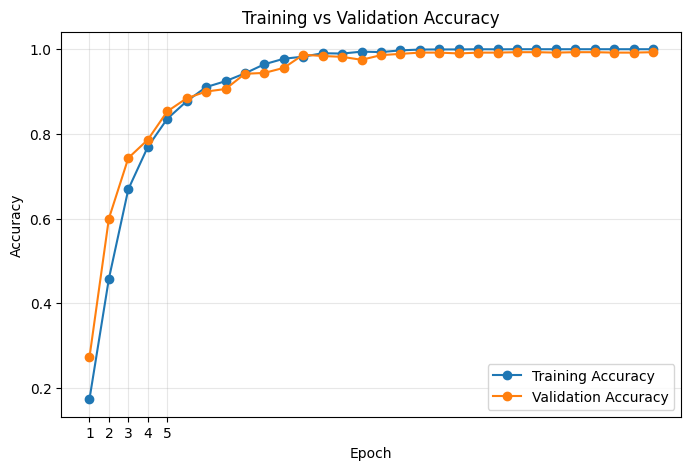

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(5), range(1, 6))
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%")


Test Loss: 0.4596
Test Accuracy: 0.8896
Test Accuracy Percentage: 88.96%


In [21]:
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
print(y_pred)

[6 5 9 ... 2 4 2]


In [23]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [24]:
predicted_labels = le.inverse_transform(
    predicted_classes
)

true_labels = le.inverse_transform(
    y_test
)

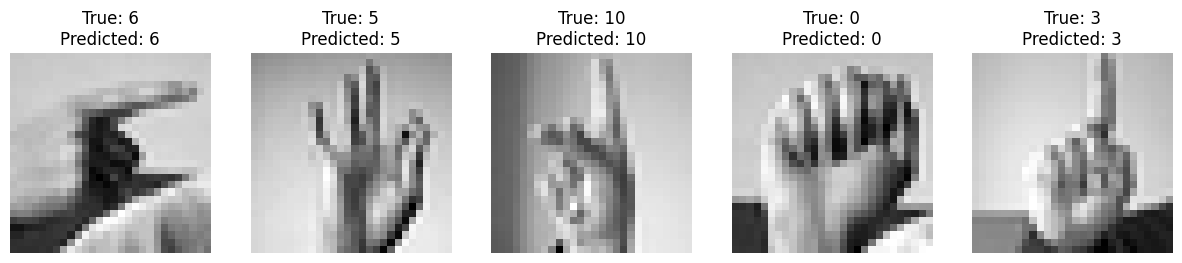

In [25]:
plt.figure(figsize=(15, 3))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        "True: " + str(true_labels[i]) +
        "\nPredicted: " + str(predicted_labels[i])
    )

    plt.axis("off")